Analysis of Netlfix data set. Using the Dataset trying to find out the kind of, number of movies, tvshows the streaming platform released. The artists it worked with the most in recent years and what shows or movies, did best with more runtime or seasons. 

In [148]:
#Importing all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [149]:
#loading the dataset
df= pd.read_csv("C:\\Users\\94san\\OneDrive\\Desktop\\Python\\netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [150]:
#Preprocessing the data
#checking for null values
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [151]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [152]:
#Changing the str to numeric values for date_added column
df["date_added"] = pd.to_numeric(df["date_added"], errors="coerce")


In [153]:
df.columns.tolist()

['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'date_added',
 'release_year',
 'rating',
 'duration',
 'listed_in',
 'description']

In [154]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["duration"] = df["duration"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Unknown")

In [155]:
df.isna().sum()

show_id            0
type               0
title              0
director           0
cast               0
country            0
date_added      8807
release_year       0
rating             0
duration           0
listed_in          0
description        0
dtype: int64

In [156]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,NaN,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,NaN,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,NaN,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,NaN,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,NaN,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [157]:
df = df.drop(columns=["show_id", "description", "date_added"])

In [158]:
df[df.duplicated()]

#No duplicate values in the dataset, at this point the dataset is clean and ready for analysis


,type,title,director,cast,country,release_year,rating,duration,listed_in


In [159]:
#how many movies and TV shows are there in the dataset
df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Has netflix released more movies or TV shows over the years? Let's visualize this trend.


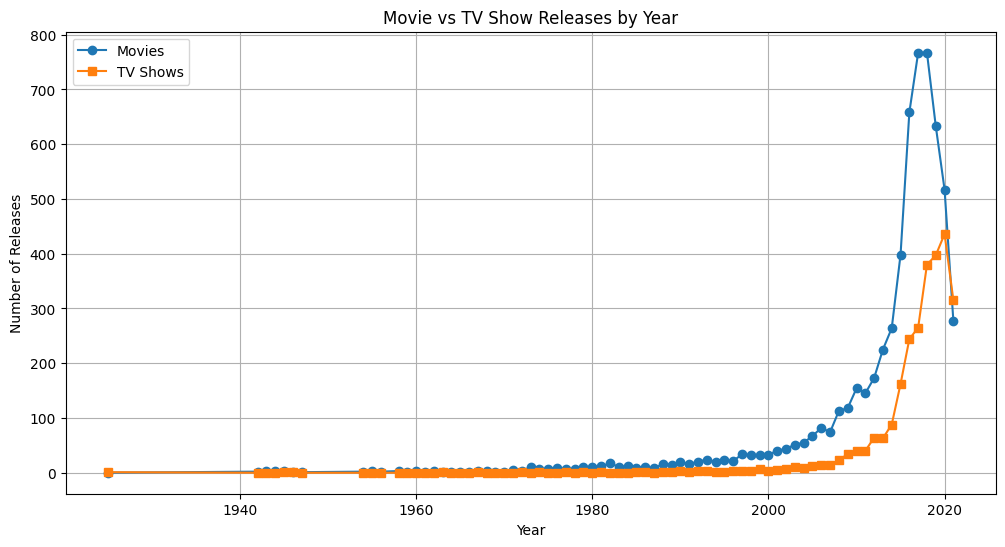

In [160]:

data_grouped = df.groupby(['release_year', 'type']).size().reset_index(name='count')

# Pivot the data for easier plotting
pivot_df = data_grouped.pivot(index='release_year', columns='type', values='count').fillna(0)

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(pivot_df.index, pivot_df['Movie'], label='Movies', marker='o')
plt.plot(pivot_df.index, pivot_df['TV Show'], label='TV Shows', marker='s')

plt.title('Movie vs TV Show Releases by Year')
plt.xlabel('Year')
plt.ylabel('Number of Releases')
plt.legend()
plt.grid(True)
plt.show()

Netflix started releasing tvshows somewhat in the years after 2000, but the gap between movie and tv show releases has reamined wide over the years. 

Text(0.5, 1.0, 'Number of Movies Released by Netflix Each Year')

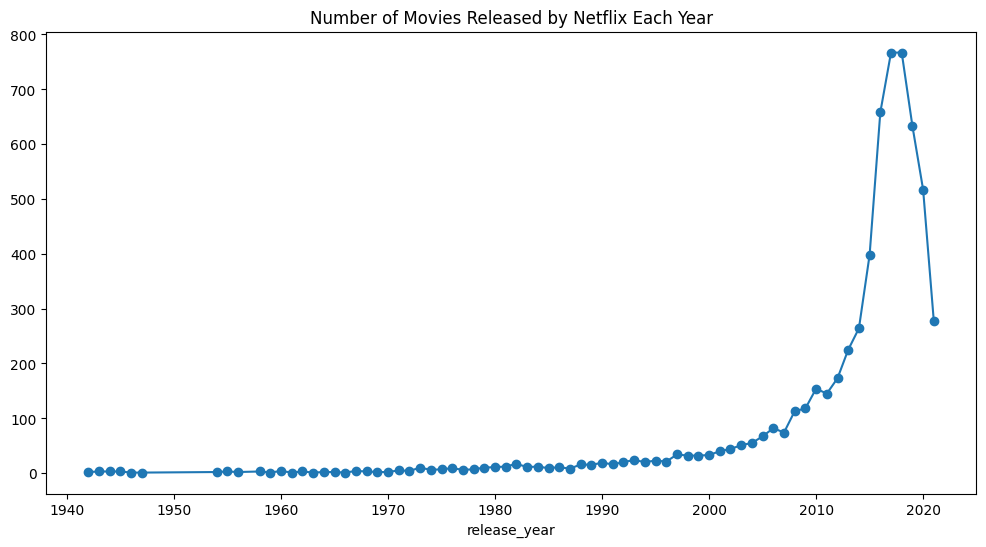

In [161]:
#How many movies has netflix released each year
df[df["type"] == "Movie"].groupby("release_year").size().plot(kind="line", marker="o", figsize=(12, 6))
plt.title("Number of Movies Released by Netflix Each Year")

Text(0.5, 1.0, 'Number of Movies and TV Shows Released by Netflix in 2019 and 2020')

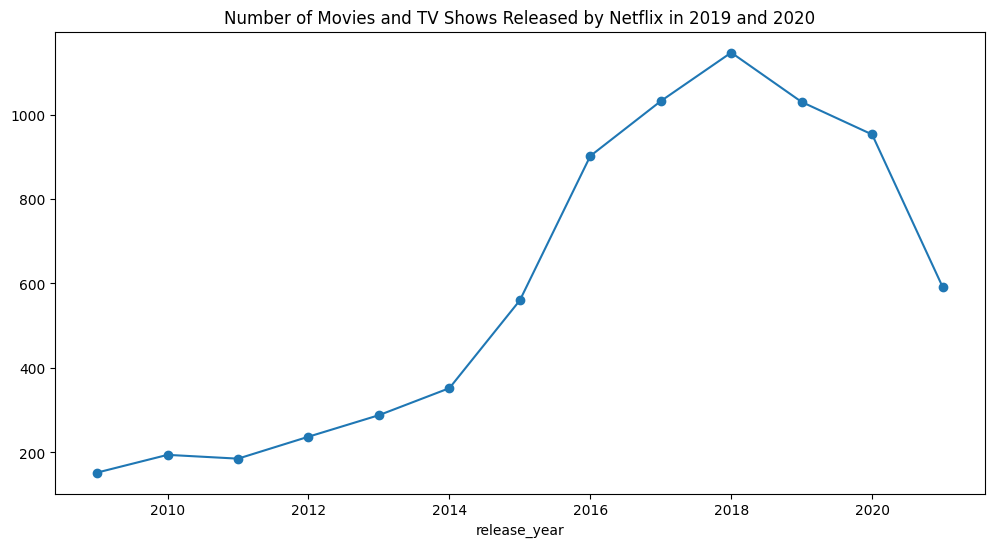

In [162]:
#Why did movies and TV shows have a significant increase in 2019 and 2020
df[df["release_year"] >= 2009].groupby("release_year").size().plot(kind="line", marker="o", figsize=(12, 6))
plt.title("Number of Movies and TV Shows Released by Netflix in 2019 and 2020")

There is a major dip in the between 2019 to 2021, possibly due to the covid pandemic, but lets see if the rating of the releases during the time also dipped. 

Text(0.5, 1.0, 'Number of Movies and TV Shows Released by Netflix in 2019 and 2020')

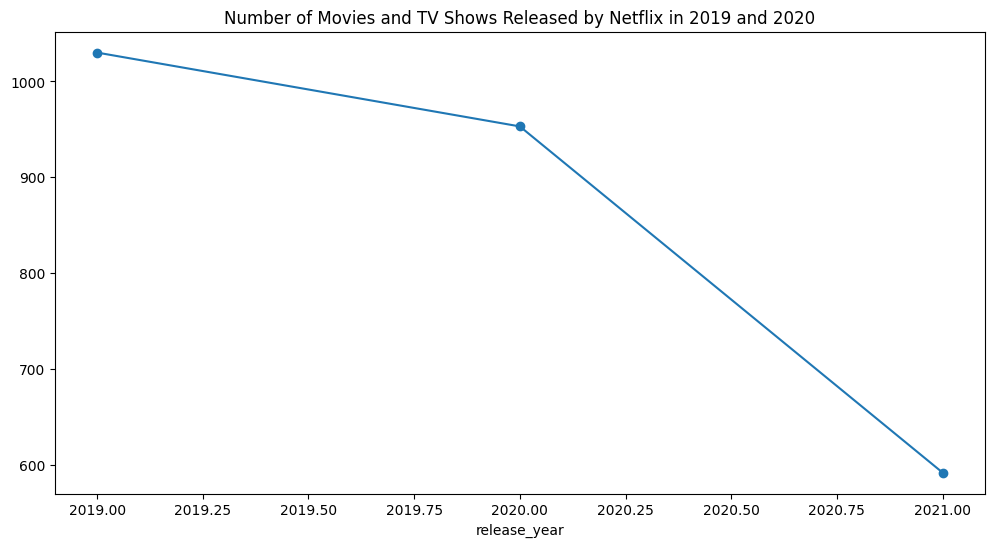

In [163]:
df[df["release_year"] >= 2019].groupby("release_year").size().plot(kind="line", marker="o", figsize=(12, 6))
plt.title("Number of Movies and TV Shows Released by Netflix in 2019 and 2020")

In [164]:
df["director"].unique()

<StringArray>
[              'Kirsten Johnson',                       'Unknown',
               'Julien Leclercq',                 'Mike Flanagan',
 'Robert Cullen, José Luis Ucha',                  'Haile Gerima',
               'Andy Devonshire',                'Theodore Melfi',
             'Kongkiat Komesiri',           'Christian Schwochow',
 ...
       'Saratswadee Wongsomphet',             'Kirati Nakintanon',
                   'Mark Risley',                   'James Brown',
                    'Ivona Juka',                        'Mu Chu',
       'Chandra Prakash Dwivedi',               'Majid Al Ansari',
                  'Peter Hewitt',                   'Mozez Singh']
Length: 4529, dtype: str

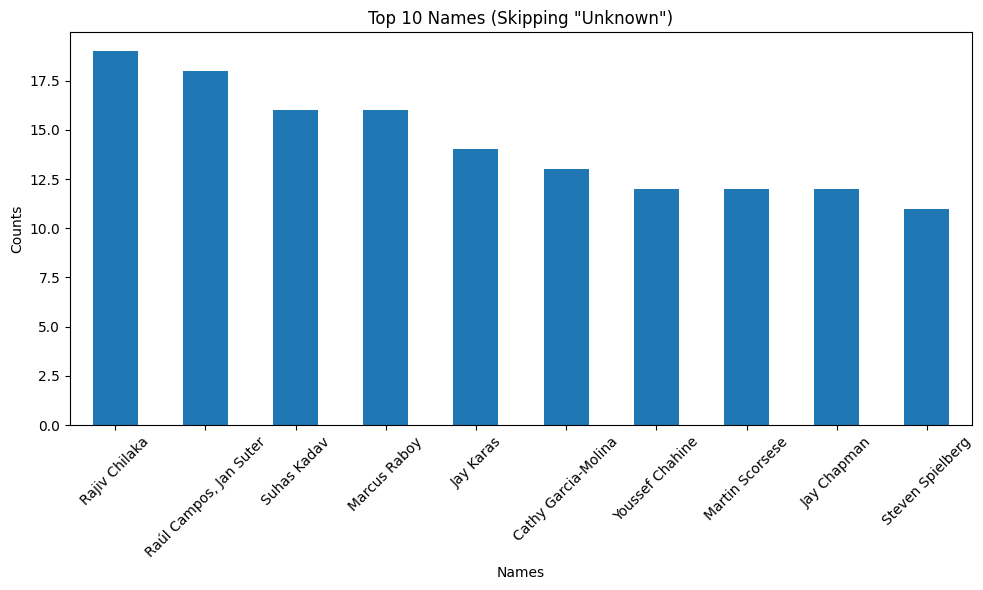

In [165]:
#Who are the top 10 directors Netflix has worked with in the dataset, skipping "Unknown"
director_unique = df['director'].value_counts()
director_filtered = director_unique.drop(labels=['Unknown'], errors='ignore').head(10)
plt.figure(figsize=(10, 6))
director_filtered.plot(kind='bar')
plt.title('Top 10 Names (Skipping "Unknown")')
plt.ylabel('Counts')
plt.xlabel('Names')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Distribution of Ratings in the Dataset')

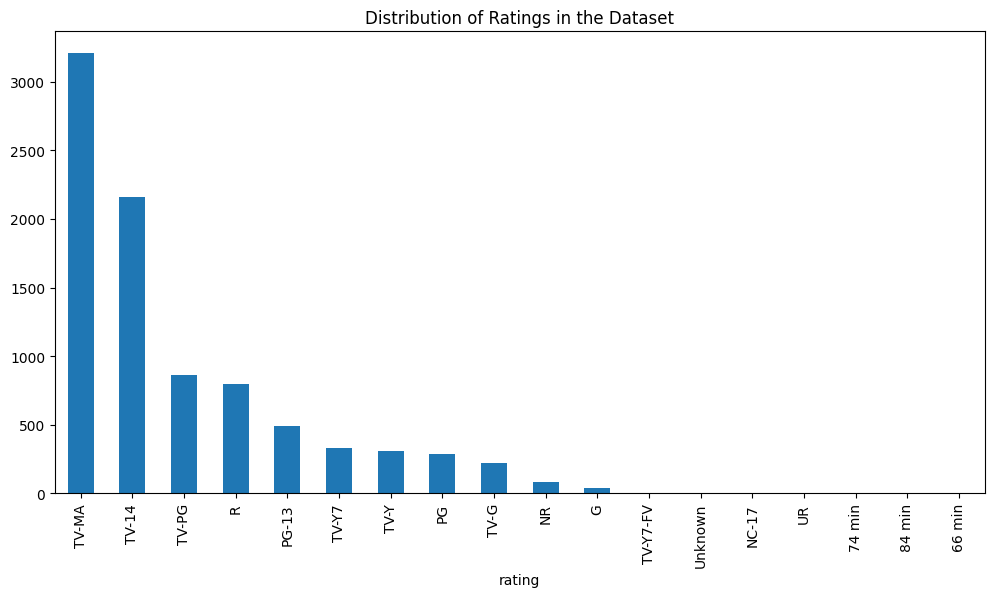

In [166]:
#Checking the kind of unique ratings in the dataset
#df["rating"].unique()
plot = df["rating"].value_counts().plot(kind="bar", figsize=(12, 6))
plt.title("Distribution of Ratings in the Dataset")

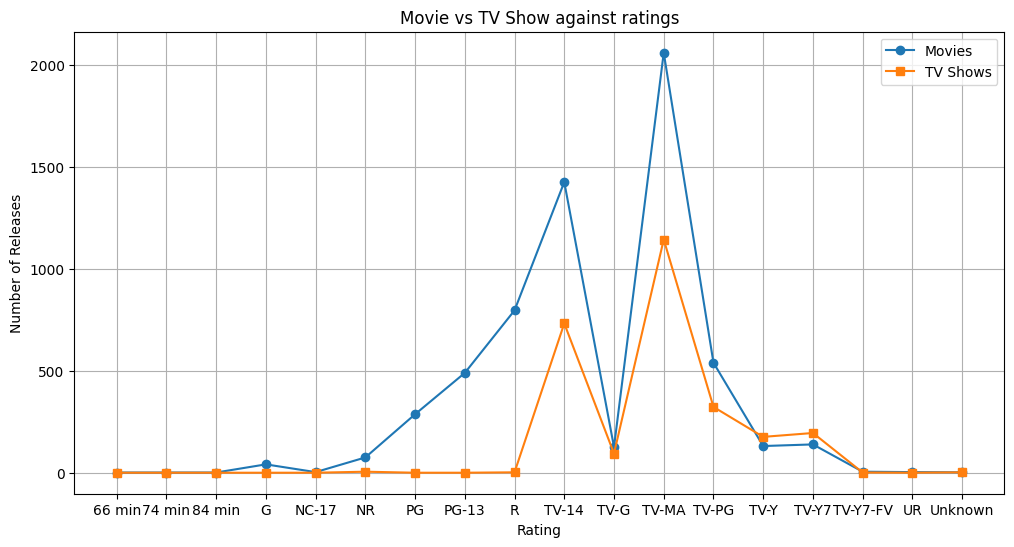

In [167]:
#Movie vs TV Show against ratings. Checking the highest kind of (ratings) movie and tv shows were made.
data_grouped_rating = df.groupby(['rating', 'type']).size().reset_index(name='count')

# Pivot the data for easier plotting
pivot_df = data_grouped_rating.pivot(index='rating', columns='type', values='count').fillna(0)

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(pivot_df.index, pivot_df['Movie'], label='Movies', marker='o')
plt.plot(pivot_df.index, pivot_df['TV Show'], label='TV Shows', marker='s')

plt.title('Movie vs TV Show against ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Releases')
plt.legend()
plt.grid(True)
plt.show()

According to the graph, TV-14 and TV-MA have seen the most movie and TV show releases on Netflix over the years. Meanwhile, TV shows of PG, PG-13 and R rating are negligible in this data set. 

<Axes: xlabel='country'>

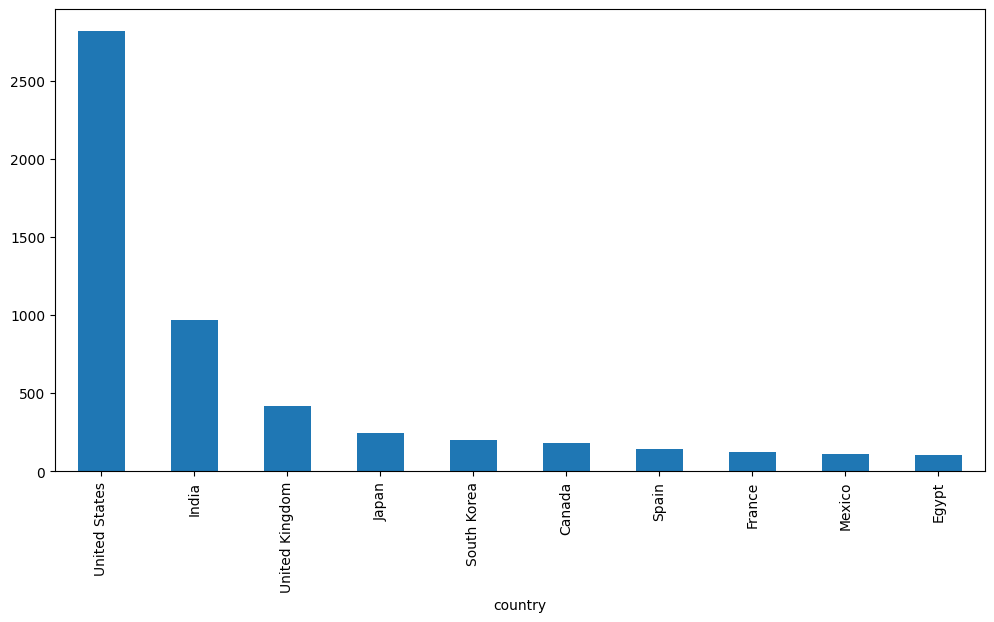

In [168]:
country_top = df['country'].value_counts()
country_2 = country_top.drop(labels=['Unknown'], errors='ignore')
plt.figure(figsize=(12, 6))
country_2.head(10).plot(kind='bar')

<Axes: xlabel='duration'>

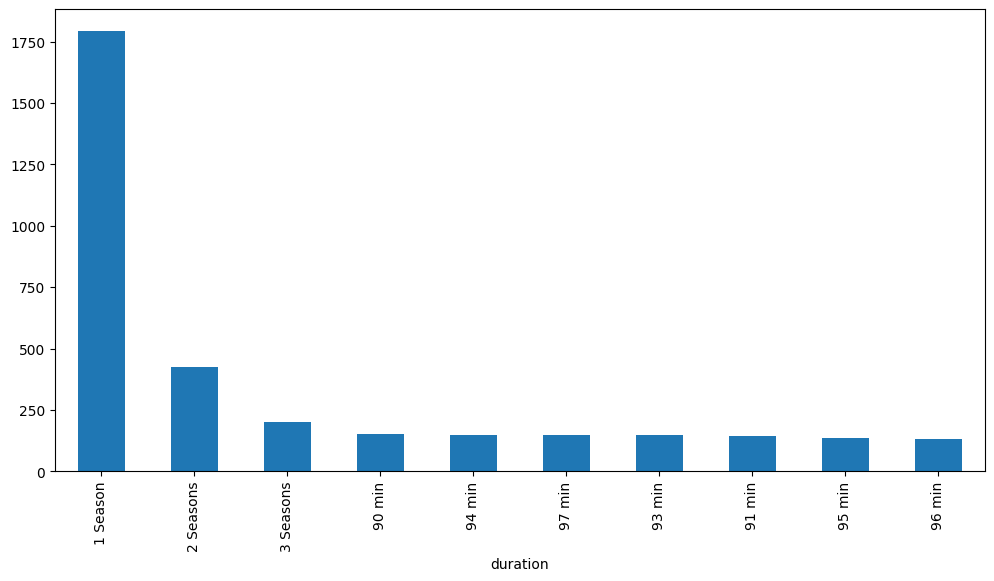

In [169]:
duration_top = df['duration'].value_counts()
duration_2 = duration_top.drop(labels=['Unknown'], errors='ignore')
plt.figure(figsize=(12, 6))
duration_2.head(10).plot(kind='bar')

For Tv shows, Netflix drops the number of shows from season 1, drastically and only a fewer reach season 3, however, movies have even lower numbers. But it seems like 90 minutes in the next most common runtime. With more data on the viewer rating, it will be easier to tell which duration is recieved best byt he audience. 

Text(0.5, 1.0, 'Highest number of movies and TV shows released by Netflix in the last few years')

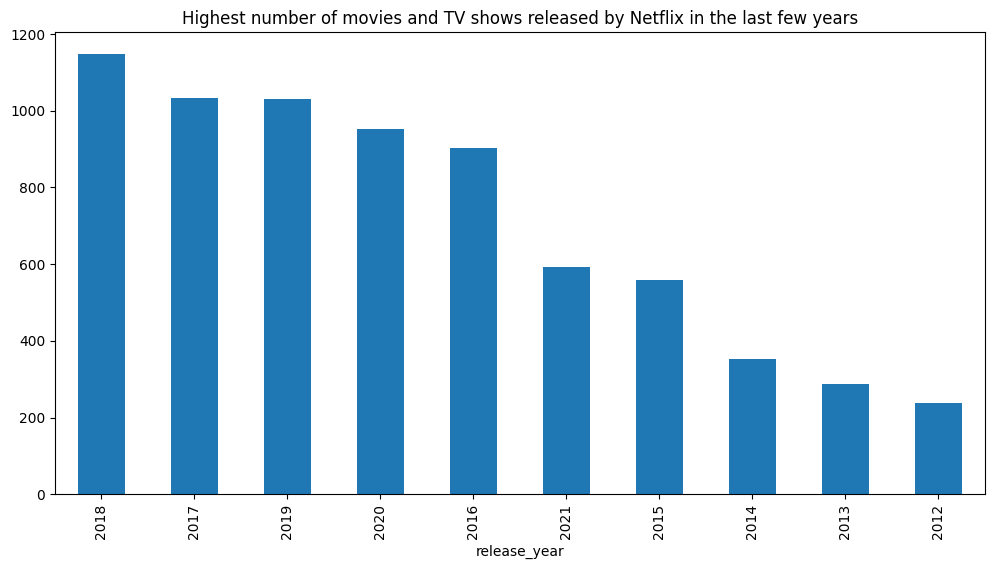

In [170]:
last_few_years = df["release_year"].value_counts()
plt.figure(figsize=(12, 6))
last_few_years.head(10).plot(kind="bar")
plt.title("Highest number of movies and TV shows released by Netflix in the last few years")